# Demo QE reconstruction from cluster simulations 

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np 
import camb 

import lensit as li
from lensit.clusterlens import lensingmap 
from lensit.misc.misc_utils import gauss_beam
from lensit.ffs_covs import ffs_cov, ell_mat

import os
import os.path as op
import matplotlib as mpl
from matplotlib import pyplot as plt

from scipy.interpolate import UnivariateSpline as spline

import healpy as hp

pbs.py : This looks like invocation on login nodes
Using finufft


In [2]:
mpl.rcParams['axes.labelsize'] = 20
mpl.rcParams['font.size'] = 20
mpl.rcParams['figure.figsize'] = 8.5, 5.5

mpl.rcParams['mathtext.fontset'] = 'cm'
mpl.rcParams['mathtext.rm'] = 'serif'
mpl.rc('text', usetex=True)
mpl.rcParams['errorbar.capsize'] = 4
mpl.rc('legend', fontsize=15)

In [3]:
def cli(cl):
    ret = np.zeros_like(cl)
    ret[np.where(cl > 0)] = 1. / cl[np.where(cl > 0)]
    return ret

def pp_to_kk(ls):
    return ls ** 2 * (ls+1) ** 2 * 0.25 

def kk_to_pp(ls):
    return cli(pp_to_kk(ls))

In [4]:
# We start by intiating CAMB which will give us the relevant cosmology 
cambinifile = 'planck_2018_acc'

pars = camb.read_ini(op.join(op.dirname(camb.__path__[0]),  'inifiles', cambinifile + '.ini'))
results = camb.get_results(pars)


In [5]:
# We define here the parameters for the profile of the cluster
# We use M200c, i.e. the mass contained in a sphere 
# whose density is 200 the critical density of the Universe at the cluster's redshift
M200 = 1e14
z = 0.7

profname = 'nfw'

# The NFW profile is truncated at R_trunc = xmax * r_s =  xmaxn * R_200c
# and we use xmaxn, defined in unit of concentration parameter
# xmaxn = xmax/c_200c, 
# where c_200c = R_200c/r_s
# Note that Zubeldia and Challinor 2019 used R_trunc = 5 R_500c, where R_500c ~ 0.7 R_200c
xmaxn = 4

profparams={'M200c':M200, 'z':z, 'xmaxn':xmaxn}

# Define here the map square patches
# This gives square patches of side npix*lpix_amin
npix = 256 # Number of pixels, should be a power of 2
lpix_amin = 0.5 # Physical size of a pixel in arcmin 

# Maximum multipole used to generate the CMB maps from the CMB power spectra
ellmaxsky = 10000 


# CMB lensing maps are reconstructed up to this lmax 
lmax_qlm = 6000

# Number of simulated maps 
nsims = 1000

# Set CMB experiment for noise level and beam
cmb_exp='S4_sayan'

# Lens only by the cluster 
# We can also lens with lss only or lss+cluster
key = 'cluster'

# We will cache things in this directory 
libdir = lensingmap.get_cluster_libdir(cambinifile, profname, key, npix, lpix_amin, ellmaxsky, M200, z, xmaxn, nsims, cmb_exp)
print(libdir)

/Users/louis/Code/LensIt/lensit_write/temp/clustermaps/camb_planck_2018_acc/cmbexp_S4_sayan/nfw_profile/lensed_by_cluster/npix256_lpix_0.5amin_lmaxsky10000/M200_1.000000E+14_z0.7_xmaxn4/1000_sims


In [6]:
# Instantiate the class containing the simulated maps 
np.random.seed(seed=42) # set a seed for random phases generations


clustermaps = lensingmap.cluster_maps(libdir, key, npix, lpix_amin, nsims, results, profparams, profilename=profname,  ellmax_sky = ellmaxsky, cmb_exp=cmb_exp)

lib_skyalm = clustermaps.lib_skyalm


 [00:00:12] Generating CMB phases ---------> 99%
 [00:00:15] Generating Noise phases ---------> 99%


In [7]:
# Input convergence map of our simulations 

kappa_input = clustermaps.len_cmbs.kappa_map
phi_input = clustermaps.len_cmbs._get_f().get_phi()

klm_input = lib_skyalm.map2alm(kappa_input)
plm_input = lib_skyalm.map2alm(phi_input)

In [8]:
ckk_in = lib_skyalm.alm2cl(klm_input)
cpp_in = lib_skyalm.alm2cl(plm_input)

ell, = np.where(lib_skyalm.get_Nell()[:ellmaxsky])

ls = np.arange(ellmaxsky+1)

# Fiducial spectra of the maps 
ckk_fid = clustermaps.haloprofile.analitic_kappa_ft(clustermaps.M200, clustermaps.z, clustermaps.xmax, ls)**2 /np.prod(lib_skyalm.lsides)
cpp_prior = ckk_fid * kk_to_pp(ls)

# Plot to check its fine
# plt.loglog(ell, ckk_in[ell])
# plt.plot(ell, cpp_in[ell]*pp_to_kk(ell))
# plt.plot(ls,  ckk_fid[ls], label='fid')
# plt.legend()


### 1. We build the quadratic estimator 

In [9]:
# QE type (here only temperature is used) 
typ = 'T'

# Hu, De Deo, Vale filtering of the gradient leg 
# (None for standard QE)
ellmax_gradleg = None


ellmax_sky = clustermaps.ellmax_sky
cls_unl, cls_len = li.get_fidcls()

# Use lensed (or unlensed) Cls in the CMB weights 
use_cls_len = False


# Define the inverse variance filtering
# Assumes Gaussian white noise in the filters 
sN_uKamin, sN_uKaminP, Beam_FWHM_amin, ellmin, ellmax = li.get_config(clustermaps.cmb_exp)

cls_noise = {'t': (sN_uKamin * np.pi / 180. / 60.) ** 2 * np.ones(clustermaps.ellmax_sky + 1),
            'q':(sN_uKaminP * np.pi / 180. / 60.) ** 2 * np.ones(clustermaps.ellmax_sky + 1),
            'u':(sN_uKaminP * np.pi / 180. / 60.) ** 2 * np.ones(clustermaps.ellmax_sky + 1)}  # simple flat noise Cls
# cl_transf = clustermaps.cl_transf

cl_transf = gauss_beam(Beam_FWHM_amin / 60. * np.pi / 180., lmax=clustermaps.ellmax_sky)
cl_transf[:ellmin] = 0 
cl_transf[ellmax+1] = 0 

lib_skyalm = clustermaps.lib_skyalm

lib_dir = op.join(clustermaps.dat_libdir, typ)

isocov = ffs_cov.ffs_diagcov_alm(lib_dir, clustermaps.lib_datalm, clustermaps.cls_unl, clustermaps.cls_unl, cl_transf, cls_noise, lib_skyalm=lib_skyalm)

In [10]:
def get_qe(idx, typ, clustermaps, isocov, lib_qlm, use_cls_len=False, ellmax_gradleg=None): 
    """
    This returns the QE estimatr for simulation index 'idx'
    """ 

    print(" I will be using data from ell=%s to ell=%s only"%(isocov.lib_datalm.ellmin, isocov.lib_datalm.ellmax))
    print(" The sky band-limit is ell=%s"%(isocov.lib_skyalm.ellmax))
 

    if typ=='QU':
        datalms = np.array([isocov.lib_datalm.map2alm(m) for m in clustermaps.maps_lib.get_sim_qumap(idx)]) 
    elif typ =='T':
        datalms = np.array([isocov.lib_datalm.map2alm(clustermaps.maps_lib.get_sim_tmap(idx))]) 
    elif typ =='TQU':
        datalms = np.array([isocov.lib_datalm.map2alm(m) for m in np.array([clustermaps.maps_lib.get_sim_tmap(idx), clustermaps.maps_lib.get_sim_qumap(idx)[0], clustermaps.maps_lib.get_sim_qumap(idx)[1]])]) 
   
 
    plmqe = 0.5 * isocov.get_qlms(typ,  isocov.get_iblms(typ, datalms, use_cls_len=use_cls_len)[0], lib_qlm, 
                                 use_cls_len=use_cls_len, ellmax_gradleg=ellmax_gradleg)[0]
    
    lib_qlm.almxfl(plmqe, N0, inplace=True)

    return  plmqe


# lib_qlm = lib_skyalm # This means we will reconstruct the lensing potential for all unlensed sky modes.
# We reconstruct the lensing potential up to lmax_qlm 
lib_qlm = ell_mat.ffs_alm_pyFFTW(clustermaps.ellmat, num_threads=clustermaps.num_threads, filt_func=lambda ell: ell <= lmax_qlm)

ell, = np.where(lib_qlm.get_Nell()[:lmax_qlm+1])

    
# Response of the QE,  qe_resp = 1/N0
qe_resp =  isocov.get_response(typ, lib_qlm, use_cls_len=use_cls_len)[0]
N0 = cli(qe_resp)

# QE for first simulation
plmqe = get_qe(0, typ, clustermaps, isocov,  lib_qlm, use_cls_len=use_cls_len, ellmax_gradleg=ellmax_gradleg)


wf_qe = np.zeros(lib_qlm.ellmax+1)
wf_qe[ell] = cpp_prior[ell] * cli(cpp_prior[ell] + N0[ell])
wf_qe[0] = 0 

plm_wf = lib_qlm.almxfl(plmqe, wf_qe, inplace=False)

 I will be using data from ell=168 to ell=4000 only
 The sky band-limit is ell=9996
Building nufft fwd plan
     _get_pmati:: cached /Users/louis/Code/LensIt/lensit_write/temp/clustermaps/camb_planck_2018_acc/cmbexp_S4_sayan/nfw_profile/lensed_by_cluster/npix256_lpix_0.5amin_lmaxsky10000/M200_1.000000E+14_z0.7_xmaxn4/1000_sims/lmaxdat4000/T/T_Pmatinv_unl_00.npy
     [00:00:00]  (total [00:00:00])   get_qlms::mult with unl Pmat  
     [00:00:00]  (total [00:00:00])   get_qlms::cartesian gradients  
     [00:00:00]  (total [00:00:00])   get_qlms::rotation to phi Omega  


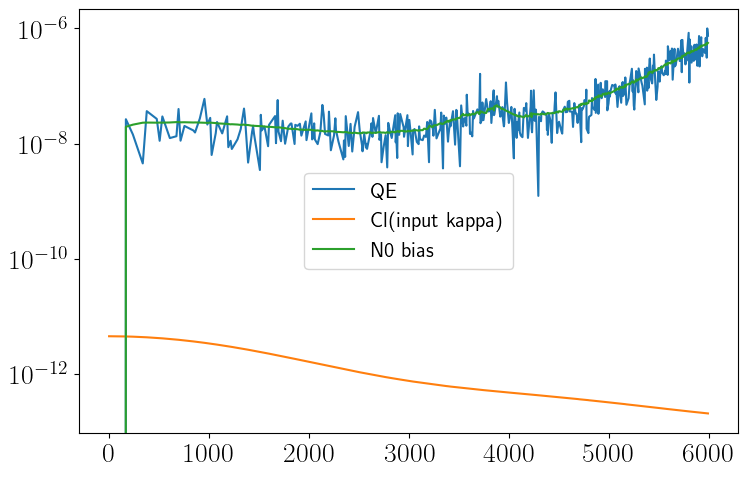

In [11]:
ell, = np.where(lib_qlm.get_Nell()[:lmax_qlm])

kappa_map =clustermaps.get_kappa_map(clustermaps.M200, clustermaps.z, xmax=clustermaps.xmax)

plt.semilogy(ell, lib_qlm.alm2cl(plmqe)[ell]  * pp_to_kk(ell) , label='QE')

plt.plot(ell, lib_qlm.map2cl(kappa_map)[ell], label='Cl(input kappa)')

plt.plot(ell, N0[ell]*pp_to_kk(ell), label='N0 bias')


plt.legend()


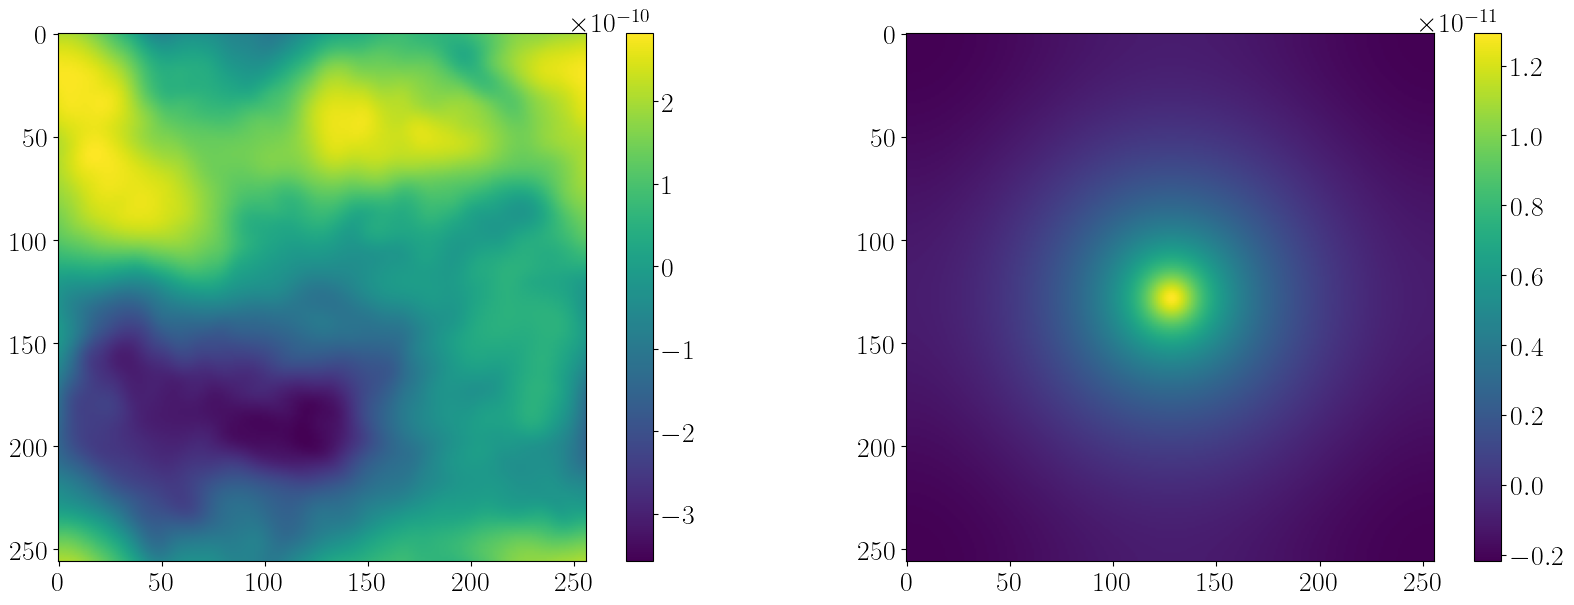

In [12]:
plm_input = lib_qlm.map2alm(phi_input)
phi_input_wf = lib_qlm.alm2map(lib_qlm.almxfl(plm_input,  wf_qe , inplace=False))

fig, axs = plt.subplots(1, 2, figsize=(12, 6),)

fig.subplots_adjust(left=0.02, bottom=0.06, right=1.4, top=0.94, wspace=0.05)
for ax, dat in zip(axs, [lib_qlm.alm2map(plm_wf), phi_input_wf]):
    im = ax.imshow(dat)
    fig.colorbar(im, ax=ax)


# 2. Run for a set of sims and take the average

In [13]:
# Define a cluster template for match filtering        

# Build template from the kappa map 
kappa_map = clustermaps.get_kappa_map(clustermaps.M200, clustermaps.z, clustermaps.xmax)
kappa_lm = lib_qlm.map2alm(kappa_map)

# Convert kappa -> phi template: kappa = ell*(ell+1)/2 * phi
ell_mode = lib_qlm.reduced_ellmat().astype(float)
ptok = ell_mode * (ell_mode + 1.) * 0.5
ptok[ptok == 0] = 1.0
phi_template_lm = kappa_lm / ptok

# Normalize by kappa0 so the matched filtering estimator returns kappa0
phi_template_lm /= clustermaps.kappa0

In [14]:
nmaps = nsims
plmqes = np.zeros_like(plmqe)
pmapsqe = np.zeros_like(phi_input_wf)
plm_wfs = np.zeros_like(plmqes)
pmap_wfs = np.zeros_like(phi_input_wf)

kappas = np.zeros(nmaps)


cpp_qes = np.zeros([nmaps, lib_qlm.ellmax+1])
cpp_qesxinput = np.zeros([nmaps, lib_qlm.ellmax+1])

    
if nsims >1:
    for idx in range(nmaps):
        print(idx)
        _plm_qe = get_qe(idx, typ, clustermaps, isocov,  lib_qlm, use_cls_len=use_cls_len, ellmax_gradleg=ellmax_gradleg)
        _plm_wf = lib_qlm.almxfl(_plm_qe, wf_qe, inplace=False)
        plmqes += _plm_qe
        plm_wfs += _plm_wf
        pmapsqe += lib_qlm.alm2map(_plm_qe)
        pmap_wfs += lib_qlm.alm2map(_plm_wf)
        cpp_qes[idx] = lib_qlm.alm2cl(_plm_qe)
        cpp_qesxinput[idx] = lib_qlm.alm2cl(_plm_qe, plm_input)
   

        # Estimate of convergence with match filtering 
        kappas[idx] = clustermaps.get_kappa0_from_sim(lmin=ellmin, lmax=ellmax, phi_obs_lm=_plm_qe, phi_template_lm=phi_template_lm, NL=N0, lib_qlm=lib_qlm)


plmqes/=nmaps
plm_wfs/=nmaps    
pmapsqe/=nmaps    
pmap_wfs/=nmaps    

        

0
 I will be using data from ell=168 to ell=4000 only
 The sky band-limit is ell=9996
Building nufft fwd plan
     [00:00:00]  (total [00:00:00])   get_qlms::mult with unl Pmat  
     [00:00:00]  (total [00:00:00])   get_qlms::cartesian gradients  
     [00:00:00]  (total [00:00:00])   get_qlms::rotation to phi Omega  
1
 I will be using data from ell=168 to ell=4000 only
 The sky band-limit is ell=9996
Building nufft fwd plan
     [00:00:00]  (total [00:00:00])   get_qlms::mult with unl Pmat  
     [00:00:00]  (total [00:00:00])   get_qlms::cartesian gradients  
     [00:00:00]  (total [00:00:00])   get_qlms::rotation to phi Omega  
2
 I will be using data from ell=168 to ell=4000 only
 The sky band-limit is ell=9996
Building nufft fwd plan
     [00:00:00]  (total [00:00:00])   get_qlms::mult with unl Pmat  
     [00:00:00]  (total [00:00:00])   get_qlms::cartesian gradients  
     [00:00:00]  (total [00:00:00])   get_qlms::rotation to phi Omega  
3
 I will be using data from ell=168 

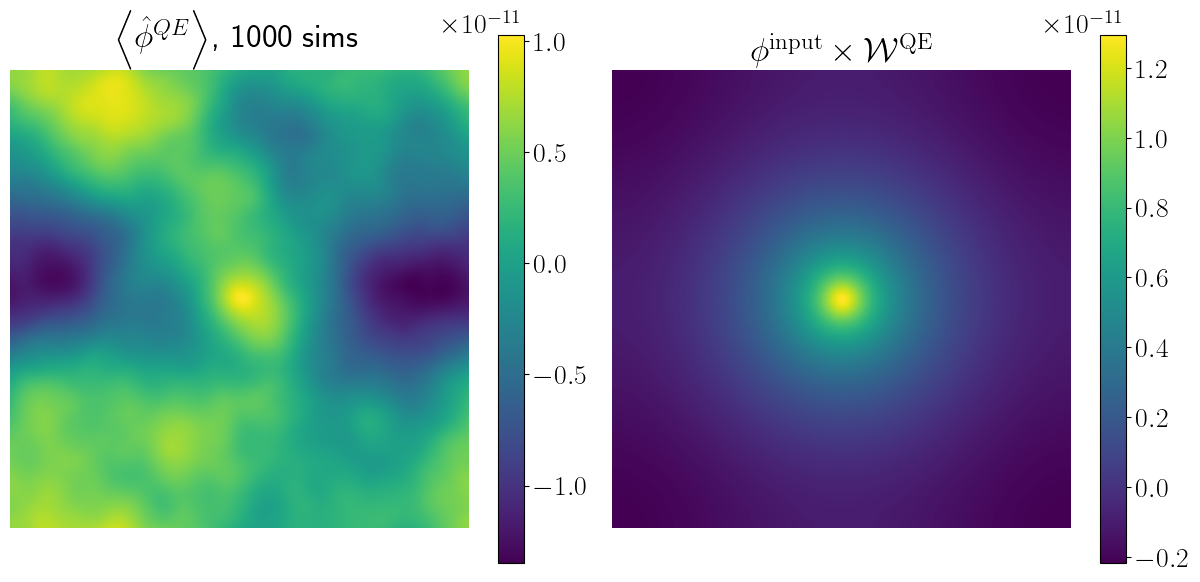

In [15]:
# plt.imshow(np.mean(np.array(pmaps), axis=0))
fig, axs = plt.subplots(1, 2, figsize=(12, 6),)

fig.subplots_adjust(left=0.02, bottom=0.06, right=1, top=0.94, wspace=0.05)

vmax = np.max(np.abs(phi_input_wf))
titles = [r'$\left< \hat \phi^{QE} \right>$' + f', {nmaps} sims', r'$\phi^{\mathrm{input}} \times \mathcal{W}^{\mathrm{QE}} $']
for ax, dat, title in zip(axs, [pmap_wfs, phi_input_wf], titles):
# for ax, dat, title in zip(axs, [np.mean(np.array(kmaps), axis=0), clustermaps.len_cmbs.kappa_map], titles):
    # im = ax.imshow(dat, vmax = vmax, vmin = -vmax, cmap = 'viridis')
    im = ax.imshow(dat)
    fig.colorbar(im, ax=ax)
    ax.set_title(title)
    ax.axis('off')

Text(0, 0.5, '$L^2 (L+1)^2 / 4 \\times C_L^{\\phi \\phi} $')

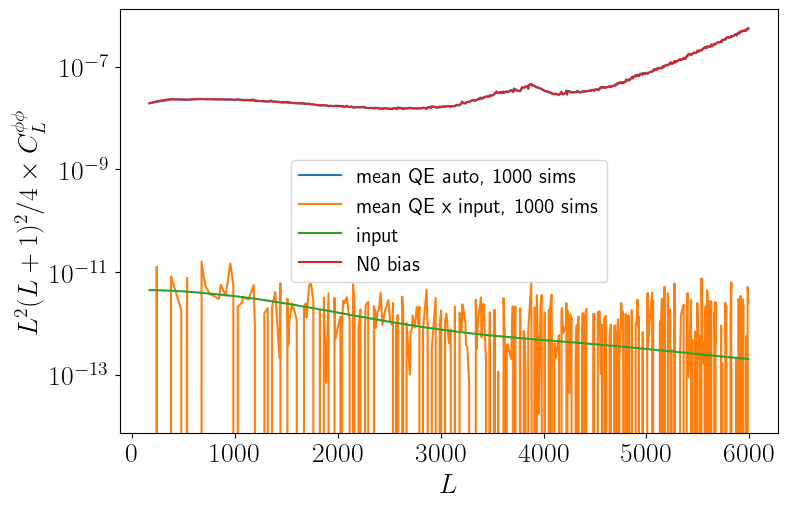

In [16]:
ell = np.where(lib_qlm.get_Nell()[:lmax_qlm+1])[0][1:]


plt.semilogy(ell, np.mean(cpp_qes, axis=0)[ell]  * pp_to_kk(ell), label=f'mean QE auto, {nsims} sims')

plt.semilogy(ell, np.mean(cpp_qesxinput, axis=0)[ell]  * pp_to_kk(ell), label=f'mean QE x input, {nsims} sims')

plt.plot(ell, lib_qlm.map2cl(phi_input)[ell]* pp_to_kk(ell), label='input')

plt.plot(ell, N0[ell]*pp_to_kk(ell), label='N0 bias')

plt.legend()

plt.xlabel(r'$L$')
plt.ylabel(r'$L^2 (L+1)^2 / 4 \times C_L^{\phi \phi} $')

# 3. Estimate the lensing convergence by match filtering 

We use a match filter to measure the converge of the clusters, following Zubelida and Challinor 2019

In [17]:
kappa0 = clustermaps.kappa0

In [18]:
print("========================QE Results========================")
print("input kappa_0 %f"%(kappa0))
print("mean kappa_0 from %i simulations is %f"%(nmaps, np.mean(kappas)))
print("error on the mean from %i simulations %f"%(nmaps, np.std(kappas)/np.sqrt(nmaps)))

========================QE Results========================
input kappa_0 0.109770
mean kappa_0 from 1000 simulations is 0.100458
error on the mean from 1000 simulations 0.010085


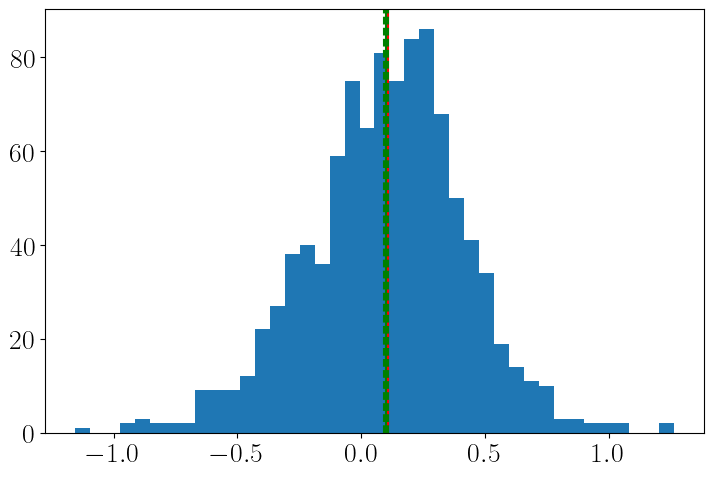

In [21]:
plt.hist(kappas, 40)
plt.axvline(kappa0, c='red')

plt.axvline(np.mean(kappas), c='green')
plt.axvline(np.mean(kappas)-np.std(kappas)/np.sqrt(nmaps), c='green', ls='--')
plt.axvline(np.mean(kappas)+np.std(kappas)/np.sqrt(nmaps), c='green', ls='--')

